Stage 1 DEA 篩選階段：

1. 基礎過濾 (Standard DEA)： 淘汰效率分數低於 0.8 的絕對劣勢資產。

2. 極端值清洗 (Super-Efficiency DEA)： 針對效率為 1.0 的資產進行極限壓力測試，揪出分數大於某個閾值（如 2.0）的投機型或資料異常標的。

3. 客觀互評 (Cross-Efficiency DEA)： 對剩餘的高品質資產池進行交叉矩陣運算，取得最終的客觀穩健分數，作為資產配置的基準。

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

def run_stage1_normalized_dea():
    # 1. 讀取 Stage 0 正規化並降維後的 DEA 專用矩陣
    try:
        df_raw = pd.read_csv("csv\\stage0_dea_ready_matrix.csv")
    except FileNotFoundError:
        print("找不到 stage0_dea_ready_matrix.csv，請先執行前段正規化。")
        return
    # 2. 資料清洗：實作「分層 DEA」，先濾除含有 NaN 的非股票型資產
    # 確保送入 linprog 的矩陣是完美的實數
    df = df_raw.dropna(subset=['Out_Diversity']).reset_index(drop=True)
    print(f"📊 載入資料：共 {len(df)} 檔 ETF 進入正規化 DEA 運算。")

    # 3. 定義投入 (Inputs) 與 產出 (Outputs) 欄位
    # 投入：越小越好 (In_Risk, In_Cost)
    input_cols = ['In_Risk', 'In_Cost']
    # 產出：越大越好 (Out_Return, Out_Liquidity, Out_Diversity)
    output_cols = ['Out_Return', 'Out_Liquidity', 'Out_Diversity']

    # 提取數值矩陣
    X = df[input_cols].values
    Y = df[output_cols].values

    n_dmus = len(df)          # 決策單元 (ETF) 數量
    n_inputs = X.shape[1]     # 投入維度數 = 2
    n_outputs = Y.shape[1]    # 產出維度數 = 3

    efficiencies = []

    print("🚀 啟動 DEA (CCR Input-Oriented) 線性規劃求解...")

    # 4. 對每一檔 ETF 分別求解線性規劃
    for k in range(n_dmus):
        # 目標函數：最大化 u^T * Y_k -> 轉為 scipy 的 Minimize -u^T * Y_k
        c = np.concatenate((np.zeros(n_inputs), -Y[k]))
        
        # 限制式 1：v^T * X_k = 1 
        A_eq = np.concatenate((X[k].reshape(1, -1), np.zeros((1, n_outputs))), axis=1)
        b_eq = np.array([1.0])
        
        # 限制式 2：-v^T * X_j + u^T * Y_j <= 0 (對所有 j)
        A_ub = np.hstack((-X, Y))
        b_ub = np.zeros(n_dmus)
        
        # 變數範圍 (Bounds)：加入 Non-Archimedean infinitesimal 防止權重為 0
        epsilon = 1e-6
        bounds = [(epsilon, None) for _ in range(n_inputs + n_outputs)]
        
        # 執行求解
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
        
        if res.success:
            eff = -res.fun
            # 處理極微小的浮點數誤差，確保最高分為 1.0
            eff = min(round(eff, 4), 1.0)
            efficiencies.append(eff)
        else:
            print(f"⚠️ 警告：{df['ETF'].iloc[k]} 求解失敗。")
            efficiencies.append(np.nan)

    # 5. 將效率分數寫回 DataFrame 並排序
    df['DEA_Score'] = efficiencies

    # 顯示排版
    display_cols = ['ETF', 'DEA_Score'] + input_cols + output_cols
    df_sorted = df[display_cols].sort_values(by='DEA_Score', ascending=False).reset_index(drop=True)

    # 篩選
    efficient_frontier = df_sorted[df_sorted['DEA_Score'] == 1.0]
    relatively_efficient = df_sorted[df_sorted['DEA_Score'] >= 0.95]

    print(f"\n=== 🏆 效率前緣標的 (DEA Score = 1.0) 共 {len(efficient_frontier)} 檔 ===")
    print(efficient_frontier[['ETF', 'DEA_Score', 'In_Risk', 'In_Cost', 'Out_Return']].head(10).to_string(index=False))

    print(f"\n具有一定競爭力的標的數量 (DEA Score >= 0.95) : {len(relatively_efficient)}")

    print(f"\n=== 📉 需要剃除的劣勢標的 (DEA Score < 0.80) 共 {len(df_sorted[df_sorted['DEA_Score'] < 0.80])} 檔 ===")
    print(df_sorted[df_sorted['DEA_Score'] < 0.80][['ETF', 'DEA_Score']].head(5).to_string(index=False))

    # 儲存包含分數的最終結果
    df_sorted.to_csv("csv\\stage1_dea_results.csv", index=False)
    print("\n✅ 已將 DEA 分數儲存至 csv\\stage1_dea_results.csv")

# 執行
run_stage1_normalized_dea()

📊 載入資料：共 46 檔 ETF 進入正規化 DEA 運算。
🚀 啟動 DEA (CCR Input-Oriented) 線性規劃求解...

=== 🏆 效率前緣標的 (DEA Score = 1.0) 共 5 檔 ===
 ETF  DEA_Score  In_Risk  In_Cost  Out_Return
  VO        1.0 0.320905   0.1000    0.426416
 VTV        1.0 0.207994   0.1000    0.483183
SCHX        1.0 0.317254   0.1000    0.470761
SCHF        1.0 0.240457   0.1000    0.634885
 VYM        1.0 0.207212   0.1125    0.514659

具有一定競爭力的標的數量 (DEA Score >= 0.95) : 8

=== 📉 需要剃除的劣勢標的 (DEA Score < 0.80) 共 22 檔 ===
 ETF  DEA_Score
 IVE     0.7978
 IJR     0.7418
 VUG     0.7342
SPYG     0.6858
 XLI     0.6682

✅ 已將 DEA 分數儲存至 csv\stage1_dea_results.csv


📊 統計圖繪製完成！已儲存為 png\dea_score_distribution.png


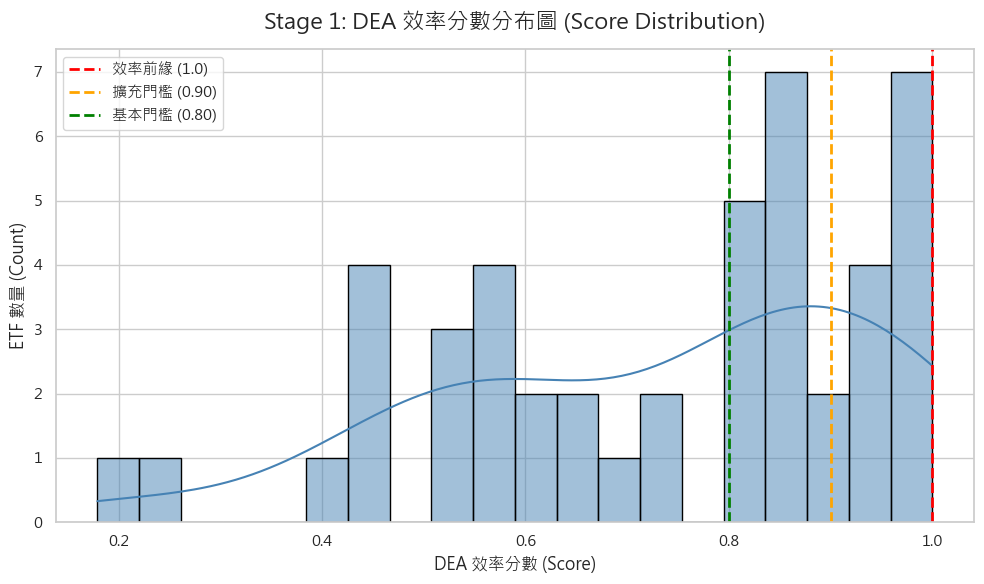

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dea_distribution():
    # 1. 讀取 DEA 結果
    try:
        df = pd.read_csv("csv\\stage1_dea_results.csv")
    except FileNotFoundError:
        print("找不到 csv\\stage1_dea_results.csv，請確認 DEA 模型已執行完畢。")
        return
    
    # 2. 設定繪圖風格與中文字型
    sns.set_theme(style="whitegrid")
    # 若在 Windows 執行可使用微軟正黑體；Mac 可改為 'PingFang HK' 或 'Arial Unicode MS'
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    # 3. 建立畫布
    fig, ax = plt.subplots(figsize=(10, 6))

    # 4. 繪製直方圖與 KDE 曲線
    # 根據資料量自動調整 bins，未來資料變多時圖形依然平滑
    sns.histplot(df['DEA_Score'], bins=20, kde=True, color='steelblue', edgecolor='black', ax=ax)

    # 5. 加上客觀閾值參考線
    ax.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='效率前緣 (1.0)')
    ax.axvline(x=0.90, color='orange', linestyle='--', linewidth=2, label='擴充門檻 (0.90)')
    ax.axvline(x=0.80, color='green', linestyle='--', linewidth=2, label='基本門檻 (0.80)')

    # 6. 設定標題與標籤
    ax.set_title('Stage 1: DEA 效率分數分布圖 (Score Distribution)', fontsize=16, pad=15)
    ax.set_xlabel('DEA 效率分數 (Score)', fontsize=12)
    ax.set_ylabel('ETF 數量 (Count)', fontsize=12)
    ax.legend()

    # 確保標籤不重疊
    plt.tight_layout()

    # 7. 儲存圖片
    output_filename = "png\\dea_score_distribution.png"
    plt.savefig(output_filename, dpi=300)
    print(f"📊 統計圖繪製完成！已儲存為 {output_filename}")

# 執行繪圖
plot_dea_distribution()

In [3]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

def run_stage1_super_efficiency_normalized():
    print("🚀 啟動超級效率模型 (Super-Efficiency DEA) 運算...")
    
    # 1. 🚨 修正：讀取「正規化且降維後」的 DEA 專用矩陣
    try:
        df_raw = pd.read_csv("csv\\stage0_dea_ready_matrix.csv")
    except FileNotFoundError:
        print("❌ 找不到 stage0_dea_ready_matrix.csv，請先執行前段正規化。")
        return
    df = df_raw.dropna(subset=['Out_Diversity']).reset_index(drop=True)

    # 2. 對齊 6 大維度
    input_cols = ['In_Risk', 'In_Cost']
    output_cols = ['Out_Return', 'Out_Liquidity', 'Out_Diversity', 'Out_Sentiment']

    X = df[input_cols].values
    Y = df[output_cols].values

    n_dmus = len(df)
    n_inputs = X.shape[1]   # 降為 2 維度
    n_outputs = Y.shape[1]  # 降為 4 維度

    super_efficiencies = []

    # 預先建立完整的 A_ub 基礎矩陣 (-X + Y)
    A_ub_base = np.hstack((-X, Y))

    # 3. 針對每檔 ETF 進行超級效率求解
    for k in range(n_dmus):
        c = np.concatenate((np.zeros(n_inputs), -Y[k]))
        
        A_eq = np.concatenate((X[k].reshape(1, -1), np.zeros((1, n_outputs))), axis=1)
        b_eq = np.array([1.0])
        
        # 核心差異：刪除第 k 列 (不與自己比較)
        A_ub_k = np.delete(A_ub_base, k, axis=0)
        b_ub_k = np.zeros(n_dmus - 1)
        
        epsilon = 1e-6
        bounds = [(epsilon, None) for _ in range(n_inputs + n_outputs)]
        
        res = linprog(c, A_ub=A_ub_k, b_ub=b_ub_k, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
        
        if res.success:
            eff = -res.fun
            super_efficiencies.append(round(eff, 4))
        else:
            # 正規化後的數據極少無解，若無解通常是強烈的離群訊號
            print(f"⚠️ 警告：{df['ETF'].iloc[k]} 求解無解 (Infeasible)。")
            super_efficiencies.append(np.nan)

    # 4. 寫回 DataFrame 並排序
    df['Super_Score'] = super_efficiencies
    df_sorted = df.sort_values(by='Super_Score', ascending=False).reset_index(drop=True)

    # 5. 分析與印出結果
    print("\n=== 🚨 疑似極端值/異類 (Super_Score > 1.5) ===")
    outliers = df_sorted[df_sorted['Super_Score'] > 1.5]
    if not outliers.empty:
        print(outliers[['ETF', 'Super_Score', 'In_Cost', 'Out_Return']].to_string(index=False))
        print("💡 洞察：這些標的分數突破天際，建議檢查是否為單一維度極端產生的數學扭曲。")
    else:
        print("無發現嚴重極端值，資料庫品質十分穩定。")

    print("\n=== 🏆 優秀且穩健的前緣標的 (1.0 <= Super_Score <= 1.5) ===")
    robust_frontiers = df_sorted[(df_sorted['Super_Score'] >= 1.0) & (df_sorted['Super_Score'] <= 1.5)]
    print(robust_frontiers[['ETF', 'Super_Score']].head(10).to_string(index=False))

    df_sorted.to_csv("csv\\stage1_super_efficiency_results.csv", index=False)
    print("\n✅ 超級效率運算完成，結果已儲存為 csv\\stage1_super_efficiency_results.csv")

# 執行模型
run_stage1_super_efficiency_normalized()

🚀 啟動超級效率模型 (Super-Efficiency DEA) 運算...

=== 🚨 疑似極端值/異類 (Super_Score > 1.5) ===
無發現嚴重極端值，資料庫品質十分穩定。

=== 🏆 優秀且穩健的前緣標的 (1.0 <= Super_Score <= 1.5) ===
 ETF  Super_Score
SCHF       1.3140
  VB       1.2606
 VTV       1.2187
  VO       1.0644
DGRO       1.0504
SCHX       1.0317
 VYM       1.0210
SCHD       1.0101
SCHG       1.0008

✅ 超級效率運算完成，結果已儲存為 csv\stage1_super_efficiency_results.csv


In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

def run_cross_efficiency_dea():
    print("啟動 Stage 1: 交叉評估 (Cross-Efficiency) 運算...")
    
    # 1. 讀取 Stage 1 第一階段 (標準 DEA) 的結果
    try:
        df_raw = pd.read_csv("csv\\stage1_dea_results.csv")
    except FileNotFoundError:
        print("找不到 csv\\stage1_dea_results.csv，請先執行標準 DEA 模型。")
        return
        
    # 2. 過濾出符合基本門檻的優質 ETF (分數 >= 0.8)
    df = df_raw[df_raw['DEA_Score'] >= 0.8].reset_index(drop=True)
    print(f"篩選完畢：共 {len(df)} 檔 ETF 進入交叉評估矩陣。")

    input_cols = ['In_Risk', 'In_Cost']
    output_cols = ['Out_Return', 'Out_Liquidity', 'Out_Diversity']

    X = df[input_cols].values
    Y = df[output_cols].values

    n_dmus = len(df)
    n_inputs = X.shape[1]
    n_outputs = Y.shape[1]

    # 建立 n x n 交叉評估矩陣
    cross_matrix = np.zeros((n_dmus, n_dmus))

    # 3. 矩陣運算核心
    for k in range(n_dmus):
        # 步驟 A: 求解 DMU_k 的標準 DEA 以取得其專屬的「最佳權重」
        c = np.concatenate((np.zeros(n_inputs), -Y[k]))
        A_eq = np.concatenate((X[k].reshape(1, -1), np.zeros((1, n_outputs))), axis=1)
        b_eq = np.array([1.0])
        A_ub = np.hstack((-X, Y))
        b_ub = np.zeros(n_dmus)
        
        epsilon = 1e-6
        bounds = [(epsilon, None) for _ in range(n_inputs + n_outputs)]
        
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
        
        if res.success:
            v_star = res.x[:n_inputs]
            u_star = res.x[n_inputs:]
            
            # 步驟 B: 使用 DMU_k 的價值觀 (權重)，去評分所有的 DMU_j
            for j in range(n_dmus):
                virtual_output = np.dot(u_star, Y[j])
                virtual_input = np.dot(v_star, X[j])
                
                if virtual_input > 0:
                    cross_matrix[k][j] = virtual_output / virtual_input
                else:
                    cross_matrix[k][j] = 0.0
        else:
            print(f"警告：DMU {df['ETF'].iloc[k]} 求解失敗。")
            cross_matrix[k, :] = np.nan

    # 4. 計算最終交叉分數 (同儕評分的平均值)
    cross_efficiency_scores = np.nanmean(cross_matrix, axis=0)

    # 5. 整合結果與輸出
    df['Cross_Score'] = np.round(cross_efficiency_scores, 4)
    
    # 依照交叉分數進行絕對排序
    df_sorted = df.sort_values(by='Cross_Score', ascending=False).reset_index(drop=True)

    print("\n=== 🏆 交叉評估最終排序 (Top 15 候選池) ===")
    display_cols = ['ETF', 'Cross_Score', 'DEA_Score'] + input_cols + output_cols
    print(df_sorted[display_cols].head(15).to_string(index=False))

    output_file = "csv\\stage1_final_candidates.csv"
    df_sorted.to_csv(output_file, index=False)
    print(f"\n資料儲存完畢：候選名單已輸出至 {output_file}")

# 執行
run_cross_efficiency_dea()

啟動 Stage 1: 交叉評估 (Cross-Efficiency) 運算...
篩選完畢：共 24 檔 ETF 進入交叉評估矩陣。

=== 🏆 交叉評估最終排序 (Top 15 候選池) ===
 ETF  Cross_Score  DEA_Score  In_Risk  In_Cost  Out_Return  Out_Liquidity  Out_Diversity
 VTV       0.9655     1.0000 0.207994   0.1000    0.483183       0.780435       0.939522
SCHF       0.9641     1.0000 0.240457   0.1000    0.634885       0.928277       0.752633
 VYM       0.8480     1.0000 0.207212   0.1125    0.514659       0.692914       0.866085
SCHD       0.8073     0.9973 0.259726   0.1375    0.559150       1.000000       0.730090
SCHX       0.7867     1.0000 0.317254   0.1000    0.470761       0.957662       0.635756
 VOO       0.7779     0.9579 0.307866   0.1000    0.471745       0.904565       0.659832
 IVV       0.7676     0.9480 0.310339   0.1000    0.475957       0.897569       0.643710
 VIG       0.7597     0.8694 0.205025   0.1125    0.437671       0.678891       0.676384
SPYV       0.7507     0.8742 0.260158   0.1125    0.455660       0.675046       0.936209
  VO     